In [1]:
# MDP exploration setup
# This notebook demonstrates:
# 1) expected-score heatmaps over a hole image,
# 2) optimal action visualization (club + aim),
# 3) per-state expected score queries.

from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
from sklearn.mixture import GaussianMixture

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "Exploration" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from Simulation.holecomponent import HoleComponent
from Simulation.golfhole import Hole
from Models.MDP import GolfHoleMDP
from Models.TrainGaussian import train_gaussian_mixture
from Utils.preprocess import preprocess_data

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/epicxflipper/UBC/CPSC440/CPSC_440_Project


/home/epicxflipper/UBC/CPSC440/CPSC_440_Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


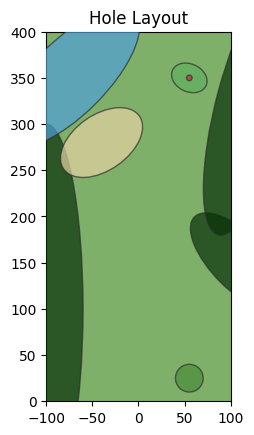

In [2]:
# Build the same hole geometry used in Simulation/HoleSetUp/hole1.py

def build_hole_1():
    components = [
        HoleComponent(center=(55, 350), semi_major_axis=20, semi_minor_axis=15, rotation=-25, comp_type="green"),
        HoleComponent(center=(55, 25), semi_major_axis=15, semi_minor_axis=15, rotation=0, comp_type="tee"),
        HoleComponent(center=(-100, 100), semi_major_axis=40, semi_minor_axis=200, rotation=0, comp_type="tree"),
        HoleComponent(center=(-75, 350), semi_major_axis=40, semi_minor_axis=100, rotation=-45, comp_type="water"),
        HoleComponent(center=(-40, 280), semi_major_axis=30, semi_minor_axis=50, rotation=-55, comp_type="bunker"),
        HoleComponent(center=(110, 150), semi_major_axis=70, semi_minor_axis=30, rotation=-45, comp_type="tree"),
        HoleComponent(center=(125, 325), semi_major_axis=40, semi_minor_axis=150, rotation=-15, comp_type="tree"),
        HoleComponent(center=(55, 350), semi_major_axis=3, semi_minor_axis=3, rotation=0, comp_type="pin"),
    ]

    hole = Hole(
        size=(200, 400),
        components=components,
        pin_location=(55, 350),
        tee_location=(55, 25),
    )
    return hole

hole = build_hole_1()
fig, ax = hole.draw()
ax.set_title("Hole Layout")
plt.show()

In [3]:
# Fit one GMM per club from Data/RG_Data.csv.
# We model each shot as [lateral_offset, distance].


DATA_PATH = PROJECT_ROOT / "Data" / "RG_Data.csv"
PLAYER_NAME = "2"
MAX_COMPONENTS = 10
MIN_SHOTS_PER_CLUB = 10

raw = preprocess_data()
player_df = raw[raw["Name"] == PLAYER_NAME].copy()

if player_df.empty:
    raise ValueError(f"No rows found for player '{PLAYER_NAME}' in {DATA_PATH}.")

gmm_list = []
club_names = []

for club, club_df in sorted(player_df.groupby("Club"), key=lambda x: x[0]):
    if len(club_df) < MIN_SHOTS_PER_CLUB:
        continue

    club_data = club_df.dropna(subset=["X", "Y"]).copy()
    idx, gmms, model_scores = train_gaussian_mixture(club_data, max_components=MAX_COMPONENTS)
    model = gmms[idx]

    gmm_list.append(model)
    club_names.append(club)

if not gmm_list:
    raise ValueError(
        "No club had enough shots to fit a GMM. Lower MIN_SHOTS_PER_CLUB or collect more data."
    )

# Add synthetic short-game clubs for around-the-green play.
class DeterministicShotModel:
    def __init__(self, lateral=0.0, distance=10.0):
        self.point = np.array([float(lateral), float(distance)], dtype=float)

    def sample(self, n_samples):
        samples = np.repeat(self.point[None, :], repeats=n_samples, axis=0)
        labels = np.zeros(n_samples, dtype=int)
        return samples, labels


gmm_list.append(DeterministicShotModel(lateral=0.0, distance=10.0))
club_names.append("PUTTER_10Y")


mdp = GolfHoleMDP(hole=hole, gmm_list=gmm_list)

print(f"Player: {PLAYER_NAME}")
print(f"Clubs used ({len(club_names)}): {club_names}")

Combined dataset shape: (1633, 4)
Initialized MDP with 861 discrete states
Player: 2
Clubs used (3): ['I7', 'W1', 'PUTTER_10Y']


In [4]:
# Use MDP.py value iteration/action generation directly (no duplicated VI logic in notebook).

def make_plot_grid(mdp, x_step=10, y_step=10):
    x_vals = np.arange(mdp.x_min, mdp.x_max + 1e-9, x_step)
    y_vals = np.arange(mdp.y_min, mdp.y_max + 1e-9, y_step)
    states = [(float(x), float(y)) for y in y_vals for x in x_vals]
    return x_vals, y_vals, states


def _progress(iterable, show_progress=True, **kwargs):
    if not show_progress:
        return iterable
    try:
        from tqdm.auto import tqdm as _tqdm
        return _tqdm(iterable, **kwargs)
    except ImportError:
        return iterable


def derive_greedy_policy(
    mdp,
    value_function,
    states,
    gamma=0.98,
    num_angle_samples=30,
    eval_samples=20,
    optimize="min",
    show_progress=True,
    progress_desc="Deriving greedy policy",
):
    policy = {}

    state_iterable = _progress(
        states,
        show_progress=show_progress,
        desc=progress_desc,
        unit="state",
    )

    for s in state_iterable:
        if mdp.is_terminal_state(s):
            policy[s] = None
            continue

        best_score = np.inf if optimize == "min" else -np.inf
        best_action = None

        for a in mdp.get_possible_actions(s, num_angle_samples=num_angle_samples):
            reward, next_dist = mdp.step(s, a, num_samples=eval_samples)
            continuation = 0.0
            for ns, p in next_dist.items():
                continuation += p * value_function.get(ns, 0.0)

            score = reward + gamma * continuation

            if optimize == "min":
                if score < best_score:
                    best_score = score
                    best_action = a
            else:
                if score > best_score:
                    best_score = score
                    best_action = a

        policy[s] = best_action

    return policy

print("Defined helpers that use GolfHoleMDP.value_iteration and GolfHoleMDP.get_possible_actions.")

Defined helpers that use GolfHoleMDP.value_iteration and GolfHoleMDP.get_possible_actions.


In [5]:
import pickle
import json
from pathlib import Path

class MDPResultsCache:
    """Helper class to save/load MDP computation results."""
    
    def __init__(self, cache_dir="mdp_cache"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
    
    def _get_cache_filename(self, player_name, grid_step, num_clubs, hole_id=None):
        """Generate unique cache filename based on problem parameters."""
        hole_str = f"_hole{hole_id}" if hole_id else ""
        return f"mdp_player{player_name}_grid{grid_step}_clubs{num_clubs}{hole_str}.pkl"
    
    def save_results(self, value_function, policy, transition_cache, 
                     player_name, grid_step, num_clubs, hole_id=None, metadata=None):
        """
        Save all computed results to disk.
        
        Args:
            value_function: Dict mapping states to values
            policy: Dict mapping states to actions
            transition_cache: Dict mapping (state, action) to (reward, next_state_dist)
            player_name: Player identifier
            grid_step: Grid discretization step size
            num_clubs: Number of clubs used
            hole_id: Optional hole identifier
            metadata: Optional dict with additional info (VI params, club names, etc.)
        """
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        filepath = self.cache_dir / filename
        
        results = {
            'value_function': value_function,
            'policy': policy,
            'transition_cache': transition_cache,
            'metadata': metadata or {},
            'player_name': player_name,
            'grid_step': grid_step,
            'num_clubs': num_clubs,
            'hole_id': hole_id,
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
        
        print(f"Saved MDP results to {filepath}")
        print(f"  - {len(value_function)} states in value function")
        print(f"  - {len(policy)} states in policy")
        print(f"  - {len(transition_cache)} cached transitions")
        
        return filepath
    
    def load_results(self, player_name, grid_step, num_clubs, hole_id=None):
        """
        Load previously computed results.
        
        Returns:
            dict with keys: value_function, policy, transition_cache, metadata
            or None if cache doesn't exist
        """
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        filepath = self.cache_dir / filename
        
        if not filepath.exists():
            print(f"No cache found at {filepath}")
            return None
        
        with open(filepath, 'rb') as f:
            results = pickle.load(f)
        
        print(f"Loaded MDP results from {filepath}")
        print(f"  - {len(results['value_function'])} states in value function")
        print(f"  - {len(results['policy'])} states in policy")
        print(f"  - {len(results['transition_cache'])} cached transitions")
        if results['metadata']:
            print(f"  - Metadata: {results['metadata']}")
        
        return results
    
    def cache_exists(self, player_name, grid_step, num_clubs, hole_id=None):
        """Check if cache file exists for given parameters."""
        filename = self._get_cache_filename(player_name, grid_step, num_clubs, hole_id)
        return (self.cache_dir / filename).exists()

In [6]:
GRID_X_STEP = mdp.grid_step
GRID_Y_STEP = mdp.grid_step
GAMMA = 0.98
VI_ITERS = 12
VI_EPSILON = 1e-3
NUM_ANGLE_SAMPLES = 12
SAMPLES_PER_ACTION = 20
SHOW_PROGRESS = True
SHOW_VI_STATE_PROGRESS = True

# Run value iteration with optimized settings
GAMMA = 0.98
VI_ITERS = 12
VI_EPSILON = 1e-3

# These control the precomputation step
PRECOMPUTE_ANGLE_SAMPLES = 5  # Fewer angles for precomputation = faster
PRECOMPUTE_SHOT_SAMPLES = 20  # Samples per action during precomputation

In [7]:
# Initialize cache manager
cache_manager = MDPResultsCache(cache_dir="mdp_cache_fixed")

# Check if we have cached results
PLAYER_NAME = "2"
GRID_STEP = mdp.grid_step
NUM_CLUBS = len(gmm_list)
HOLE_ID = "hole1"  # Change this if you have multiple holes

if cache_manager.cache_exists(PLAYER_NAME, GRID_STEP, NUM_CLUBS, HOLE_ID):
    print("Found cached results! Loading...")
    cached = cache_manager.load_results(PLAYER_NAME, GRID_STEP, NUM_CLUBS, HOLE_ID)
    
    value_function = cached['value_function']
    policy = cached['policy']
    
    # Restore transition cache to MDP object
    mdp._transition_cache = cached['transition_cache']
    
    print("Cache loaded successfully!")
    
else:
    print("No cache found. Computing from scratch...")
    
    # Precomputation parameters
    PRECOMPUTE_ANGLE_SAMPLES = 5
    PRECOMPUTE_SHOT_SAMPLES = 20
    
    # Value iteration parameters
    GAMMA = 1
    VI_ITERS = 12
    VI_EPSILON = 1e-3
    
    # Step 1: Precompute transitions (one-time cost)
    print("\n=== Step 1: Precomputing Transitions ===")
    mdp.precompute_transitions(
        num_samples=PRECOMPUTE_SHOT_SAMPLES, 
        show_progress=True
    )
    
    # Step 2: Run value iteration
    print("\n=== Step 2: Running Value Iteration ===")
    value_function = mdp.value_iteration(
        max_iterations=VI_ITERS,
        discount_factor=GAMMA,
        epsilon=VI_EPSILON,
        show_progress=True,
        num_angle_samples=PRECOMPUTE_ANGLE_SAMPLES,
        num_samples=PRECOMPUTE_SHOT_SAMPLES,
    )
    
    # Step 3: Derive policy
    print("\n=== Step 3: Deriving Greedy Policy ===")
    x_vals, y_vals, plot_states = make_plot_grid(mdp, x_step=GRID_STEP, y_step=GRID_STEP)
    
    policy = derive_greedy_policy(
        mdp,
        value_function,
        plot_states,
        gamma=GAMMA,
        num_angle_samples=PRECOMPUTE_ANGLE_SAMPLES,
        eval_samples=PRECOMPUTE_SHOT_SAMPLES,
        optimize="min",
        show_progress=True,
        progress_desc="Deriving greedy policy",
    )
    
    # Step 4: Save results for future use
    print("\n=== Step 4: Saving Results ===")
    metadata = {
        'gamma': GAMMA,
        'vi_iterations': VI_ITERS,
        'epsilon': VI_EPSILON,
        'angle_samples': PRECOMPUTE_ANGLE_SAMPLES,
        'shot_samples': PRECOMPUTE_SHOT_SAMPLES,
        'club_names': club_names,
        'converged': True,  # You could track this in VI
    }
    
    cache_manager.save_results(
        value_function=value_function,
        policy=policy,
        transition_cache=mdp._transition_cache,
        player_name=PLAYER_NAME,
        grid_step=GRID_STEP,
        num_clubs=NUM_CLUBS,
        hole_id=HOLE_ID,
        metadata=metadata
    )

print("\n=== Ready to visualize! ===")



No cache found. Computing from scratch...

=== Step 1: Precomputing Transitions ===
Precomputing transitions for 861 states...


Precomputing transitions: 100%|██████████| 861/861 [18:43<00:00,  1.30s/state]


Cached 15498 state-action transitions

=== Step 2: Running Value Iteration ===


Value iteration: 100%|██████████| 12/12 [00:02<00:00,  4.54iter/s, max_diff=3.15]



=== Step 3: Deriving Greedy Policy ===


Deriving greedy policy: 100%|██████████| 861/861 [18:06<00:00,  1.26s/state]


=== Step 4: Saving Results ===
Saved MDP results to mdp_cache_fixed/mdp_player2_grid10_clubs3_holehole1.pkl
  - 861 states in value function
  - 861 states in policy
  - 15498 cached transitions

=== Ready to visualize! ===


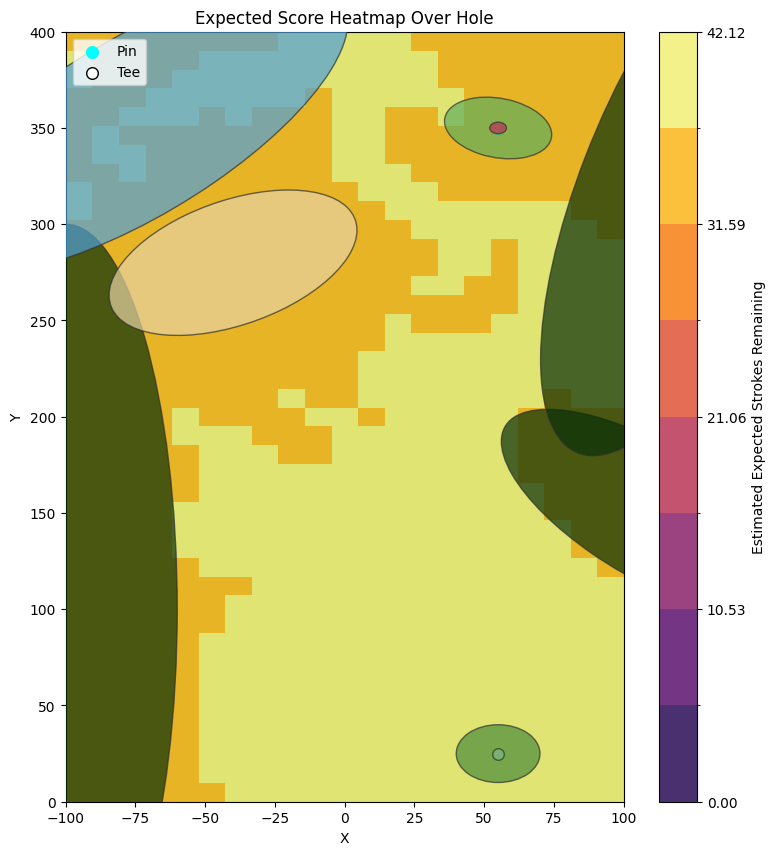

In [8]:
# 1) Heatmap: expected score from each position, overlaid on the hole geometry.
x_vals, y_vals, plot_states = make_plot_grid(
    mdp,
    x_step=GRID_X_STEP,
    y_step=GRID_Y_STEP,
)
# Convert value map to expected strokes map.
# Values are penalty-like, so expected strokes is approximated by -value.
score_grid = np.zeros((len(y_vals), len(x_vals)), dtype=float)
for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):
        score_grid[iy, ix] = max(0.0, -value_function.get((float(x), float(y)), 0.0))

# Draw directly on the hole axes so the heatmap uses the same coordinate system
# as the course geometry.
fig, ax = hole.draw()
fig.set_size_inches(9, 10)

# Use a darker, banded palette so differences in stroke counts stand out more
# against the course image.
max_score = float(np.max(score_grid)) if score_grid.size else 1.0
max_score = max(1.0, max_score)
num_bands = 8
boundaries = np.linspace(0.0, max_score, num_bands + 1)
shot_cmap = ListedColormap(plt.cm.inferno(np.linspace(0.15, 0.95, num_bands)))
shot_norm = BoundaryNorm(boundaries, shot_cmap.N, clip=True)

heat = ax.imshow(
    score_grid,
    extent=[x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]],
    origin="lower",
    cmap=shot_cmap,
    norm=shot_norm,
    alpha=0.85,
    aspect="auto",
)

cbar = plt.colorbar(heat, ax=ax, boundaries=boundaries, ticks=np.linspace(0.0, max_score, 5))
cbar.set_label("Estimated Expected Strokes Remaining")

ax.scatter([mdp.pin_location[0]], [mdp.pin_location[1]], c="cyan", s=70, label="Pin")
ax.scatter([mdp.tee_location[0]], [mdp.tee_location[1]], c="white", s=70, edgecolors="black", label="Tee")
ax.set_xlim(mdp.x_min, mdp.x_max)
ax.set_ylim(mdp.y_min, mdp.y_max)
ax.set_title("Expected Score Heatmap Over Hole")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc="upper left")
plt.show()

In [9]:
mdp_cache = MDPResultsCache(cache_dir="mdp_cache_fixed")
mdp_cache.load_results(player_name=PLAYER_NAME, grid_step=GRID_X_STEP, num_clubs=len(club_names), hole_id="hole1")

Loaded MDP results from mdp_cache_fixed/mdp_player2_grid10_clubs3_holehole1.pkl
  - 861 states in value function
  - 861 states in policy
  - 15498 cached transitions
  - Metadata: {'gamma': 1, 'vi_iterations': 12, 'epsilon': 0.001, 'angle_samples': 5, 'shot_samples': 20, 'club_names': ['I7', 'W1', 'PUTTER_10Y'], 'converged': True}


{'value_function': {(-100.0, 0.0): -36.0,
  (-100.0, 10.0): -36.0,
  (-100.0, 20.0): -36.0,
  (-100.0, 30.0): -36.0,
  (-100.0, 40.0): -36.0,
  (-100.0, 50.0): -36.0,
  (-100.0, 60.0): -36.0,
  (-100.0, 70.0): -36.0,
  (-100.0, 80.0): -36.0,
  (-100.0, 90.0): -36.0,
  (-100.0, 100.0): -36.0,
  (-100.0, 110.0): -36.0,
  (-100.0, 120.0): -36.0,
  (-100.0, 130.0): -36.0,
  (-100.0, 140.0): -36.0,
  (-100.0, 150.0): -36.0,
  (-100.0, 160.0): -36.0,
  (-100.0, 170.0): -36.0,
  (-100.0, 180.0): -36.0,
  (-100.0, 190.0): -36.0,
  (-100.0, 200.0): -36.0,
  (-100.0, 210.0): -36.0,
  (-100.0, 220.0): -36.0,
  (-100.0, 230.0): -36.0,
  (-100.0, 240.0): -36.0,
  (-100.0, 250.0): -36.0,
  (-100.0, 260.0): -36.0,
  (-100.0, 270.0): -36.0,
  (-100.0, 280.0): -36.0,
  (-100.0, 290.0): -36.0,
  (-100.0, 300.0): -36.0,
  (-100.0, 310.0): -36.95,
  (-100.0, 320.0): -36.95,
  (-100.0, 330.0): -36.75,
  (-100.0, 340.0): -36.7,
  (-100.0, 350.0): -36.7,
  (-100.0, 360.0): -36.7,
  (-100.0, 370.0): -36.75,
 

ValueError: Argument C has a size 0 which does not match 98, the number of arrow positions

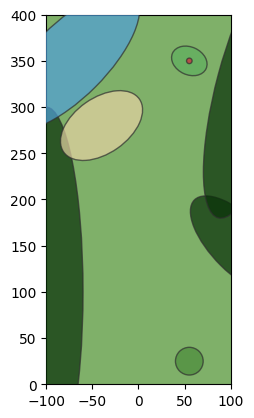

In [10]:
# ---- CLEAN POLICY VISUALIZATION ----

X, Y, U, VEC = [], [], [], []
club_for_state = []

DOWNSAMPLE = 3  # <-- KEY CONTROL (increase if still cluttered)

C = []  # <-- NEW

for iy, y in enumerate(y_vals):
    for ix, x in enumerate(x_vals):

        if iy % DOWNSAMPLE != 0 or ix % DOWNSAMPLE != 0:
            continue

        s = (float(x), float(y))
        a = policy.get(s)
        if a is None:
            continue

        club_idx, tx, ty = a
        dx = tx - x
        dy = ty - y

        norm = np.hypot(dx, dy)
        if norm < 1e-6:
            continue

        dx /= norm
        dy /= norm

        ARROW_LENGTH = 10

        X.append(x)
        Y.append(y)
        U.append(dx * ARROW_LENGTH)
        VEC.append(dy * ARROW_LENGTH)

        # 🔥 THIS IS THE IMPORTANT PART
        val = value_function.get(s, 0.0)
        strokes = -val  # convert to expected strokes
        C.append(strokes)

# ---- DRAW ----
fig, ax = hole.draw()

q = ax.quiver(
    X,
    Y,
    U,
    VEC,
    club_for_state,
    cmap="tab10",
    angles="xy",
    scale_units="xy",
    scale=1,
    pivot="tail",
    alpha=0.8,
)

# ---- REPLACE COLORBAR WITH LEGEND ----
import matplotlib.patches as mpatches

unique_clubs = sorted(set(club_for_state))
handles = []

cmap = plt.get_cmap("tab10")

for c in unique_clubs:
    label = club_names[c] if c < len(club_names) else f"club_{c}"
    color = cmap(c % 10)
    handles.append(mpatches.Patch(color=color, label=label))

ax.legend(handles=handles, title="Club", loc="upper right")

# ---- CLEAN AXES ----
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

# ---- PIN ----
ax.scatter(*mdp.pin_location, c="cyan", s=80)

ax.set_xlim(mdp.x_min, mdp.x_max)
ax.set_ylim(mdp.y_min, mdp.y_max)

ax.set_title("Optimal Policy (Direction = Aim, Color = Club)")

plt.show()

In [11]:
def get_best_action(state, policy, mdp):
    """
    Get the best action to take from a given state.
    
    Args:
        state: (x, y) tuple representing ball position
        policy: Dict mapping states to best actions (from derive_greedy_policy)
        mdp: GolfHoleMDP object
    
    Returns:
        (club_index, target_x, target_y) or None if terminal state
    """
    # Snap to nearest grid state since policy is discretized
    grid_state = mdp._snap_to_grid(state[0], state[1])
    
    if grid_state in policy:
        return policy[grid_state]
    
    # If state not in policy, find nearest state
    nearest_state = mdp._find_nearest_state(grid_state, list(policy.keys()))
    return policy.get(nearest_state)


# Example usage:
current_position = (25.0, 150.0)  # Ball at x=25, y=150
best_action = get_best_action(current_position, policy, mdp)

if best_action is None:
    print("Already at the pin!")
else:
    club_idx, target_x, target_y = best_action
    print(f"Best action from {current_position}:")
    print(f"  Club: {club_names[club_idx]}")
    print(f"  Aim at: ({target_x:.1f}, {target_y:.1f})")

Best action from (25.0, 150.0):
  Club: W1
  Aim at: (100.4, 276.6)


In [12]:
# Add this cell to your notebook to diagnose what's happening

def diagnose_state(state, mdp, policy, value_function, club_names):
    """Detailed diagnosis of what's happening at a state."""
    state = tuple(float(v) for v in state)
    print(f"\n{'='*70}")
    print(f"DIAGNOSING STATE: {state}")
    print(f"{'='*70}")
    
    # Check if terminal
    is_term = mdp.is_terminal_state(state)
    print(f"Is terminal: {is_term}")
    
    # Value
    value = value_function.get(state, 0.0)
    print(f"Value: {value:.2f}")
    print(f"Expected strokes: {-value:.2f}")
    
    if is_term:
        print("State is terminal, no actions.")
        return
    
    # Get all actions and their Q-values
    actions = mdp.get_possible_actions(state, num_angle_samples=5)
    print(f"\nTotal actions available: {len(actions)}")
    
    # Evaluate each action
    action_values = []
    for action in actions:
        club_idx, target_x, target_y = action
        
        # Get transition
        cache_key = (state, action)
        if cache_key in mdp._transition_cache:
            reward, next_dist = mdp._transition_cache[cache_key]
        else:
            reward, next_dist = mdp.step(state, action, num_samples=20)
        
        # Compute Q-value
        next_value = sum(prob * value_function.get(ns, 0.0) for ns, prob in next_dist.items())
        q_value = reward + 0.98 * next_value
        
        action_values.append({
            'club': club_names[club_idx],
            'club_idx': club_idx,
            'target': (target_x, target_y),
            'reward': reward,
            'next_value': next_value,
            'q_value': q_value,
            'next_states': len(next_dist),
        })
    
    # Sort by Q-value (best = least negative)
    action_values.sort(key=lambda x: x['q_value'], reverse=True)
    
    print(f"\nTop 5 actions (best to worst):")
    for i, av in enumerate(action_values[:5]):
        print(f"\n{i+1}. Club: {av['club']}")
        print(f"   Target: ({av['target'][0]:.1f}, {av['target'][1]:.1f})")
        print(f"   Immediate reward: {av['reward']:.3f}")
        print(f"   Expected next value: {av['next_value']:.3f}")
        print(f"   Q-value: {av['q_value']:.3f}")
        print(f"   Next states: {av['next_states']}")
    
    # Show policy action
    policy_action = policy.get(state)
    if policy_action:
        club_idx, tx, ty = policy_action
        print(f"\n{'='*70}")
        print(f"POLICY CHOSE: {club_names[club_idx]} -> ({tx:.1f}, {ty:.1f})")
        
        # Find this in action_values
        for i, av in enumerate(action_values):
            if (av['club_idx'] == club_idx and 
                abs(av['target'][0] - tx) < 0.1 and 
                abs(av['target'][1] - ty) < 0.1):
                print(f"This was ranked #{i+1} out of {len(action_values)}")
                break

# Test from tee
diagnose_state(mdp.tee_location, mdp, policy, value_function, club_names)

# Test from a fairway position
diagnose_state((0.0, 150.0), mdp, policy, value_function, club_names)

# Test from near green
diagnose_state((10.0, 280.0), mdp, policy, value_function, club_names)


DIAGNOSING STATE: (55.0, 25.0)
Is terminal: False
Value: 0.00
Expected strokes: -0.00

Total actions available: 18

Top 5 actions (best to worst):

1. Club: I7
   Target: (112.4, 163.6)
   Immediate reward: -3.000
   Expected next value: 0.000
   Q-value: -3.000
   Next states: 1

2. Club: W1
   Target: (112.4, 163.6)
   Immediate reward: -3.000
   Expected next value: 0.000
   Q-value: -3.000
   Next states: 1

3. Club: W1
   Target: (84.3, 172.1)
   Immediate reward: -3.000
   Expected next value: 0.000
   Q-value: -3.000
   Next states: 1

4. Club: I7
   Target: (84.3, 172.1)
   Immediate reward: -2.100
   Expected next value: -16.915
   Q-value: -18.677
   Next states: 7

5. Club: W1
   Target: (55.0, 350.0)
   Immediate reward: -1.100
   Expected next value: -35.453
   Q-value: -35.844
   Next states: 15

DIAGNOSING STATE: (0.0, 150.0)
Is terminal: False
Value: -38.35
Expected strokes: 38.35

Total actions available: 18

Top 5 actions (best to worst):

1. Club: W1
   Target: (55.

In [13]:
print(f"Transition cache entries: {len(mdp._transition_cache)}")
print(f"States: {len(mdp.all_states)}")
print(f"Expected entries (approx): {len(mdp.all_states)} × 18 actions = {len(mdp.all_states) * 18}")

Transition cache entries: 15498
States: 861
Expected entries (approx): 861 × 18 actions = 15498


In [14]:
terminal_count = sum(1 for s in mdp.all_states if mdp.is_terminal_state(s))
print(f"Terminal states: {terminal_count}")
print(f"Pin location: {mdp.pin_location}")
print(f"Is pin terminal? {mdp.is_terminal_state(tuple(mdp.pin_location))}")

Terminal states: 0
Pin location: [ 55 350]
Is pin terminal? True


In [15]:
# Check what happens from a state near the pin
near_pin = mdp._snap_to_grid(mdp.pin_location[0] + 5, mdp.pin_location[1] + 5)
print(f"Testing state near pin: {near_pin}")
print(f"Is terminal: {mdp.is_terminal_state(near_pin)}")
print(f"Distance to pin: {np.linalg.norm(np.array(near_pin) - mdp.pin_location):.1f}")

actions = mdp.get_possible_actions(near_pin, num_angle_samples=3)
print(f"Actions from near pin: {len(actions)}")

if actions:
    action = actions[0]
    reward, next_dist = mdp.step(near_pin, action, num_samples=100)
    print(f"Sample action: {action}")
    print(f"Reward: {reward}")
    print(f"Next states: {next_dist}")

Testing state near pin: (60.0, 360.0)
Is terminal: False
Distance to pin: 11.2
Actions from near pin: 12
Sample action: (0, 55.0, 350.0)
Reward: -3.0
Next states: {(60.0, 360.0): 1.0}
